# Épiphanie Boutique Sales Analysis: Identifying Best-Selling Products and Revenue Drivers

## Introduction

Épiphanie Boutique is a small retail business that sells shoes, bags, and accessories. 
Understanding customer demand and product performance is essential for making informed 
inventory and purchasing decisions.

In this project, I analyze order data from the store to explore sales patterns, identify the 
most popular products, and determine which items generate the highest revenue.

The datasets used in this analysis come from Shopify:

* **order_export_1.csv** – an order-item level dataset containing information on individual items sold in each order (product name, quantity, price, etc.).
* **product_export_1.csv** – a product-level dataset containing information about the items available in the store.

**Note:** Épiphanie Boutique is located in Burkina Faso, where digital data collection systems are not always fully developed. To improve record keeping, the store owner implemented Shopify to manually record orders. However, because data entry is performed manually, the dataset may contain entry errors or inconsistencies.

Although the store has been operating since 2020, Shopify Starter began being used to record transactions in 2022.

---
## Asking Questions
Based on the available datasets, this analysis aims to answer the following questions:
- Q1 : Which products generate the highest revenue?
- Q2 : Which items are the best-selling products?
- Q3 : What are the most demanded shoe sizes?
- Q4 : How are sales distributed across product categories?
- Q5: Does opening a physical store change sales?

# Data Wrangling - Products Dataset

We will prepare the environment, load and assess dataset. Subsequently, we also clean and process the data for analysis.

## Preparing the Environment

In [25]:
import pandas as pd
import numpy as np

products = pd.read_csv('EpiphanieBoutique/products_export_1.csv')

### Assess Data

In this step, we view the dataset and get basic information.

In [26]:
products.head()

,Handle,Title,Body (HTML),Vendor,Product Category,Type,Tags,Published,Option1 Name,Option1 Value,...,Style de bout (product.metafields.shopify.toe-style),Produits complémentaires (product.metafields.shopify--discovery--product_recommendation.complementary_products),Produits connexes (product.metafields.shopify--discovery--product_recommendation.related_products),Paramètres des produits connexes (product.metafields.shopify--discovery--product_recommendation.related_products_display),Mises en avant de produits dans la recherche (product.metafields.shopify--discovery--product_search_boost.queries),Variant Image,Variant Weight Unit,Variant Tax Code,Cost per item,Status
0,casablancaaa,Casablancaaa,NaN,Épiphanie Boutique,Apparel & Accessories > Shoes > Sandals,Chaussures,"arrivage_2026_02, Talons plats",False,Pointure,7-5,...,NaN,NaN,NaN,NaN,NaN,NaN,kg,NaN,13152.0,draft
1,casablancaaa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,...,NaN,NaN,NaN,NaN,NaN,NaN,kg,NaN,13152.0,NaN
2,casablancaaa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,...,NaN,NaN,NaN,NaN,NaN,NaN,kg,NaN,13152.0,NaN
3,casablancaaa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41,...,NaN,NaN,NaN,NaN,NaN,NaN,kg,NaN,13152.0,NaN
4,casablancaaa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,kg,NaN,13152.0,NaN


In [27]:
# Basic information of dataset
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 79 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Handle                                                                                                                     968 non-null    object 
 1   Title                                                                                                                      396 non-null    object 
 2   Body (HTML)                                                                                                                290 non-null    object 
 3   Vendor                                                                                                                     396 non

In the product dataset, the first entry for each product corresponds to the general product information. 
The entries that follow represent the different variants of that product. These variants typically differ 
by attributes such as size or color.

For the purpose of this analysis, I will focus only on the following variables:

- Handle  
- Title  
- Vendor  
- Product Category  
- Type  
- Tags  
- Variant SKU  
- Variant Price  
- Variant Inventory Qty  
- Cost per item  
- Status

In [28]:
products_final = products[[
    "Handle",
    "Title",
    "Vendor",
    "Product Category",
    "Type",
    "Tags",
    "Variant SKU",
    "Variant Price",
    "Variant Inventory Qty",
    "Cost per item",
    "Status"
]].copy()

### Create Field

Now, let's look at the product type :

In [29]:

products_final['Type']

#Note the label are in french


0       Chaussures
1              NaN
2              NaN
3              NaN
4              NaN
          ...     
963    Sacs à main
964            NaN
965    Sacs à main
966            NaN
967            NaN
Name: Type, Length: 968, dtype: object

In [30]:
products_final["Type"].unique()

array(['Chaussures', nan, 'Bijoux', 'Parfums', 'Sacs à main',
       'Crèmes et lotions', 'Nettoyants pour le corps', 'Mocassin',
       'Rouge à lèvres', 'Talons Hauts', 'Crayon à lèvres',
       'Brillant à lèvres', 'Maquillage pour les yeux', 'Sandales',
       'Déodorant', 'Crayons sourcils', 'Maquillage', 'Mascara'],
      dtype=object)

Looking at this, I notice that
* We have information for the item category only for it's first category.
* I need to Harmonize to a higher hierarchy.

In [31]:
#Let'S fill the missing value : 
products_final["Type"] = products_final["Type"].ffill()
products_final["Type"].unique()

array(['Chaussures', 'Bijoux', 'Parfums', 'Sacs à main',
       'Crèmes et lotions', 'Nettoyants pour le corps', 'Mocassin',
       'Rouge à lèvres', 'Talons Hauts', 'Crayon à lèvres',
       'Brillant à lèvres', 'Maquillage pour les yeux', 'Sandales',
       'Déodorant', 'Crayons sourcils', 'Maquillage', 'Mascara'],
      dtype=object)

In [32]:
# Then, let's harmonize everything using a function : 
def map_business_category(cat):

    if pd.isna(cat):
        return "Unknown"

    cat = str(cat).lower()

    categories = {
        "Shoes": ["chaussures", "mocassin", "sandales", "talons hauts"],
        "Accessories": ["bijoux"],
        "Bags": ["sacs à main"],
        "Make up": [
            "rouge à lèvres", "crayon à lèvres", "brillant à lèvres",
            "maquillage pour les yeux", "crayons sourcils", "maquillage", "mascara"
        ],
        "Beauty": [
            "parfums", "crèmes et lotions", "nettoyants pour le corps", "déodorant"
        ]
    }

    for category, keywords in categories.items():
        if any(word in cat for word in keywords):
            return category

    if cat == "uncategorized":
        return "Unknown"

    return "Other"


# Apply function
products_final["ProductType"] = products_final["Type"].apply(map_business_category)

# Inspect results
products_final["ProductType"].value_counts(dropna=False)

# Drop unnecessary columns
products_final = products_final.drop(columns=["Product Category", "Type"])

products_final.head(10)

,Handle,Title,Vendor,Tags,Variant SKU,Variant Price,Variant Inventory Qty,Cost per item,Status,ProductType
0,casablancaaa,Casablancaaa,Épiphanie Boutique,"arrivage_2026_02, Talons plats",NaN,17500.0,1.0,13152.0,draft,Shoes
1,casablancaaa,NaN,NaN,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
2,casablancaaa,NaN,NaN,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
3,casablancaaa,NaN,NaN,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
4,casablancaaa,NaN,NaN,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
5,jenni,Jennii,Épiphanie Boutique,"arrivage_2026_02, sacs-a-main",NaN,17500.0,2.0,13152.0,draft,Shoes
6,jenni,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Shoes
7,mattea,Mattea,Épiphanie Boutique,"arrivage_2026_02, Talons plats",NaN,17500.0,1.0,13152.0,draft,Shoes
8,mattea,NaN,NaN,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
9,mattea,NaN,NaN,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes


In [34]:
# We fill the value for the other colunm : 
products_final["Title"] = products_final["Title"].ffill()
products_final["Vendor"] = products_final["Vendor"].ffill()
products_final["Cost per item"] = products_final["Cost per item"].ffill()

products_final.head(10)

,Handle,Title,Vendor,Tags,Variant SKU,Variant Price,Variant Inventory Qty,Cost per item,Status,ProductType
0,casablancaaa,Casablancaaa,Épiphanie Boutique,"arrivage_2026_02, Talons plats",NaN,17500.0,1.0,13152.0,draft,Shoes
1,casablancaaa,Casablancaaa,Épiphanie Boutique,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
2,casablancaaa,Casablancaaa,Épiphanie Boutique,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
3,casablancaaa,Casablancaaa,Épiphanie Boutique,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
4,casablancaaa,Casablancaaa,Épiphanie Boutique,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
5,jenni,Jennii,Épiphanie Boutique,"arrivage_2026_02, sacs-a-main",NaN,17500.0,2.0,13152.0,draft,Shoes
6,jenni,Jennii,Épiphanie Boutique,NaN,NaN,NaN,NaN,13152.0,NaN,Shoes
7,mattea,Mattea,Épiphanie Boutique,"arrivage_2026_02, Talons plats",NaN,17500.0,1.0,13152.0,draft,Shoes
8,mattea,Mattea,Épiphanie Boutique,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes
9,mattea,Mattea,Épiphanie Boutique,NaN,NaN,17500.0,1.0,13152.0,NaN,Shoes


Ideally, I want to merge the product dataset with the order dataset so that each order can be broken down by product type (e.g., Shoes vs Bags vs Accessories).

However, in the order dataset, item names are typically entered using the structure:

**Title – Variant** (where the variant is often a size or color).

To merge both datasets, I first create a standardized **base title** that removes variant information and formatting differences (case, extra spaces, parentheses). I then build a lookup table mapping each base title to its product type and cost per item.

In [57]:

products_final["base_title"] = (
    products_final["Title"]
    .str.lower()
    .str.strip()
    .str.split("-").str[0]
    .str.split("(").str[0]
    .str.strip()
)
products_final.head(10)


base_to_cat = (
    products_final
    .dropna(subset=["base_title", "ProductType"])
    .drop_duplicates("base_title")
    .set_index("base_title")[["ProductType", "Cost per item"]]
)
print(base_to_cat)



                   ProductType  Cost per item
base_title                                   
casablancaaa             Shoes        13152.0
jennii                   Shoes        13152.0
mattea                   Shoes        13152.0
m5110                    Shoes        11080.0
m5340                    Shoes         8442.0
...                        ...            ...
the berries            Make up         4273.0
the nubian             Make up         5750.0
sac à bandoulière         Bags         9000.0
mascara allongeant     Make up         2529.0
sacs avec poignées        Bags         8623.0

[268 rows x 2 columns]


# Data Wrangling - Order Dataset

We will prepare the e
nvironment, load and assess dataset. Subsequently, we also clean and process the data for analysis.

In [58]:
import pandas as pd
import numpy as np

orders = pd.read_csv('EpiphanieBoutique/orders_export_1.csv')

### Assess Data

In [59]:
orders.head()

,Name,Email,Financial Status,Paid at,Fulfillment Status,Fulfilled at,Accepts Marketing,Currency,Subtotal,Shipping,...,Tax 5 Value,Phone,Receipt Number,Duties,Billing Province Name,Shipping Province Name,Payment ID,Payment Terms Name,Next Payment Due At,Payment References
0,#1719,NaN,paid,2026-02-26 12:58:53 -0500,fulfilled,2026-02-26 12:58:53 -0500,no,XOF,15000.0,0.0,...,NaN,2.266610e+10,10-1136,NaN,NaN,NaN,rejBFwg9GwIuAk76mjCN5HeGK,NaN,NaN,rejBFwg9GwIuAk76mjCN5HeGK
1,#1718,NaN,paid,2026-02-25 13:18:41 -0500,fulfilled,2026-02-25 13:18:41 -0500,no,XOF,5000.0,0.0,...,NaN,8.613253e+12,10-1135,NaN,NaN,NaN,rx2ihcbbe3SRLx6lUnsKCuAE7,NaN,NaN,rx2ihcbbe3SRLx6lUnsKCuAE7
2,#1717,NaN,paid,2026-02-25 10:19:23 -0500,fulfilled,2026-02-25 10:19:23 -0500,no,XOF,12500.0,0.0,...,NaN,2.265793e+10,10-1134,NaN,NaN,NaN,rOEh0S8uLAlYj3JdoO1fjjwWF,NaN,NaN,rOEh0S8uLAlYj3JdoO1fjjwWF
3,#1716,NaN,paid,2026-02-25 06:34:18 -0500,fulfilled,2026-02-25 06:34:18 -0500,no,XOF,12500.0,0.0,...,NaN,2.267566e+10,10-1133,NaN,NaN,NaN,rX4ESBSYBBlCPigP4rJBSlJAp,NaN,NaN,rX4ESBSYBBlCPigP4rJBSlJAp
4,#1715,NaN,paid,2026-02-25 05:52:08 -0500,fulfilled,2026-02-25 05:52:08 -0500,no,XOF,12500.0,0.0,...,NaN,2.267656e+10,10-1132,NaN,NaN,NaN,rEuBdNouLgPdh902RL5meGrLx,NaN,NaN,rEuBdNouLgPdh902RL5meGrLx


In [60]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Name                         1196 non-null   object 
 1   Email                        133 non-null    object 
 2   Financial Status             718 non-null    object 
 3   Paid at                      703 non-null    object 
 4   Fulfillment Status           718 non-null    object 
 5   Fulfilled at                 706 non-null    object 
 6   Accepts Marketing            718 non-null    object 
 7   Currency                     718 non-null    object 
 8   Subtotal                     718 non-null    float64
 9   Shipping                     718 non-null    float64
 10  Taxes                        718 non-null    float64
 11  Total                        718 non-null    float64
 12  Discount Code                285 non-null    object 
 13  Discount Amount   

In the order dataset, each entry is at the item-order

For the purpose of this analysis, I will delete some variables:


In [61]:
# Drop prefix columns
cols_to_remove = [
    col for col in orders.columns
    if col.startswith("Billing")
    or col.startswith("Shipping ")  
    or col.startswith("Tax")
    or col.startswith("Duties")
]

# Drop specific columns
extra_cols = [
    'Discount Code','Employee','Risk Level','Device ID','Payment References',
    'Note Attributes','Outstanding Balance','Next Payment Due At',
    'Currency','Notes','Location','Phone','Payment ID','Payment Reference',
    'Id','Tags','Receipt Number','Payment Terms Name'
]

orders_final = orders.drop(columns=cols_to_remove + extra_cols, errors="ignore")
#orders_final

Now, I harmonize the title in the order data, and them map the title to the type and cost that we derive from the product.

In [62]:

orders_final["title"] = (
    orders_final["Lineitem name"]
    .str.lower()
    .str.strip()
    .str.split("-").str[0]
    .str.split("(").str[0]
    .str.strip()
)
orders_final.head(10)

type_map = base_to_cat["ProductType"].to_dict()
cost_map = base_to_cat["Cost per item"].to_dict()

orders_final["ProductType"] = orders_final["title"].map(type_map)
orders_final["Cost per item"] = orders_final["title"].map(cost_map)

#orders_final

Let's look at the unmatche one and see if we can classify by hand !

In [63]:
unmatched = orders_final[orders_final["ProductType"].isna()][
    ["Lineitem name", "title"]
].drop_duplicates()

unmatched

manual_map = {
    "sac blanc": "Bags",
    "sac jaune": "Bags",
    "sac rouge paris": "Bags",
    "sac vert": "Bags",        
    "sac-vert": "Bags",  
    "sac": "Bags", 
    "infaillible transparent": "Make up",
    "gloss lifter": "Make up",
    "testeurs brumes&parfums": "Beauty",
    "testeur flirtini": "Beauty",
    "powder kiss liquid colour": "Make up",
    "rouge à lèvres retro matte": "Make up",
    "body cream": "Beauty",
    "bougie bbw": "Beauty",

    "frais envoie": "Shipping/Fees",
    "supplement": "Shipping/Fees",

    "kiaraa": "Shoes",
    "azalea camel": "Shoes",
    "sandales tapette blanc": "Shoes",
    "sandales natté noir": "Shoes",
    "sandales natté marron": "Shoes",
    "noura mules": "Shoes",
}

mask = orders_final["ProductType"].isna()
orders_final.loc[mask, "ProductType"] = orders_final.loc[mask, "title"].map(manual_map)

orders_final

,Name,Email,Financial Status,Paid at,Fulfillment Status,Fulfilled at,Accepts Marketing,Subtotal,Shipping,Total,...,Lineitem fulfillment status,Cancelled at,Payment Method,Refunded Amount,Vendor,Source,Lineitem discount,title,ProductType,Cost per item
0,#1719,NaN,paid,2026-02-26 12:58:53 -0500,fulfilled,2026-02-26 12:58:53 -0500,no,15000.0,0.0,15000.0,...,fulfilled,NaN,Cash,0.0,Épiphanie Boutique,pos,0,m5521,Shoes,9805.0
1,#1718,NaN,paid,2026-02-25 13:18:41 -0500,fulfilled,2026-02-25 13:18:41 -0500,no,5000.0,0.0,5000.0,...,fulfilled,NaN,Cash,0.0,Épiphanie Boutique,pos,0,bijoux,Accessories,2635.0
2,#1717,NaN,paid,2026-02-25 10:19:23 -0500,fulfilled,2026-02-25 10:19:23 -0500,no,12500.0,0.0,12500.0,...,fulfilled,NaN,Cash,0.0,Épiphanie Boutique,pos,0,carla,Shoes,9049.0
3,#1716,NaN,paid,2026-02-25 06:34:18 -0500,fulfilled,2026-02-25 06:34:18 -0500,no,12500.0,0.0,12500.0,...,fulfilled,NaN,Cash,0.0,Épiphanie Boutique,pos,0,carla,Shoes,9049.0
4,#1715,NaN,paid,2026-02-25 05:52:08 -0500,fulfilled,2026-02-25 05:52:08 -0500,no,12500.0,0.0,12500.0,...,fulfilled,NaN,Cash,0.0,Épiphanie Boutique,pos,0,m5470,Shoes,10323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1191,#1005,sidgomsayanluciennekon@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,fulfilled,NaN,NaN,NaN,Épiphanie Boutique,NaN,0,rouge à lèvres,Make up,2012.0
1192,#1004,wendlasida@yahoo.fr,paid,2022-04-18 19:03:33 -0400,fulfilled,2022-04-18 19:03:32 -0400,no,25000.0,0.0,25000.0,...,fulfilled,NaN,Cash,0.0,Épiphanie Boutique,pos,0,gwelissa,Shoes,17072.0
1193,#1003,sidgomsayanluciennekon@gmail.com,voided,NaN,unfulfilled,NaN,yes,25000.0,0.0,25000.0,...,pending,2022-05-19 12:32:09 -0400,manual,0.0,Épiphanie Boutique,iphone,0,harlem,Shoes,13648.0
1194,#1002,myriamdesiree@hotmail.com,paid,2022-04-18 10:43:29 -0400,fulfilled,2022-04-18 10:43:28 -0400,no,20000.0,0.0,20000.0,...,fulfilled,NaN,Cash,0.0,Épiphanie Boutique,pos,0,rherillan,Shoes,13648.0


Just checking if all the product from the order are categorized. 

In [64]:
orders_final.loc[
    orders_final["ProductType"].isna(),
    ["Lineitem name", "title", "ProductType"]
]
print("Yes" if orders_final["ProductType"].notna().all() else "No")

Yes


### Completing the data cleaning 

In [65]:
# Convert dates
orders_final["Paid at"] = pd.to_datetime(orders_final["Paid at"], errors="coerce", utc=True)
orders_final["Created at"] = pd.to_datetime(orders_final["Created at"], errors="coerce", utc=True)


In [66]:
#Extract the shoes size from Lineitem name for only shoes
mask = orders_final["ProductType"].eq("Shoes")

orders_final.loc[mask, "Shoe Size"] = (
    orders_final.loc[mask, "Lineitem name"]
    .astype(str)
    .str.extract(r'(?<!\d)(3[5-9]|4[0-5])(?:\.(?:5))?(?!\d)')[0]
)

orders_final["Shoe Size"] = pd.to_numeric(orders_final["Shoe Size"], errors="coerce")

orders_final[["Lineitem name","Shoe Size"]].head(20)

orders_final["Shoe Size"].value_counts().sort_index()


Shoe Size
36.0      5
37.0     38
38.0     83
39.0    151
40.0    168
41.0    148
42.0     64
43.0      7
45.0      1
Name: count, dtype: int64

## Analyzing the data

In [101]:
df = orders_final
df["Financial Status"].value_counts().sort_index()

Financial Status
paid                  686
partially_refunded      5
pending                 2
refunded               19
voided                  6
Name: count, dtype: int64

Keep only real financial statuses such as paid, refunded or partially refunded. 


In [102]:
df = df[
    df["Financial Status"].isin(["paid","refunded","partially_refunded"])
].copy()
df

,Name,Email,Financial Status,Paid at,Fulfillment Status,Fulfilled at,Accepts Marketing,Subtotal,Shipping,Total,...,Cancelled at,Payment Method,Refunded Amount,Vendor,Source,Lineitem discount,title,ProductType,Cost per item,Shoe Size
0,#1719,NaN,paid,2026-02-26 17:58:53+00:00,fulfilled,2026-02-26 12:58:53 -0500,no,15000.0,0.0,15000.0,...,NaN,Cash,0.0,Épiphanie Boutique,pos,0,m5521,Shoes,9805.0,41.0
1,#1718,NaN,paid,2026-02-25 18:18:41+00:00,fulfilled,2026-02-25 13:18:41 -0500,no,5000.0,0.0,5000.0,...,NaN,Cash,0.0,Épiphanie Boutique,pos,0,bijoux,Accessories,2635.0,NaN
2,#1717,NaN,paid,2026-02-25 15:19:23+00:00,fulfilled,2026-02-25 10:19:23 -0500,no,12500.0,0.0,12500.0,...,NaN,Cash,0.0,Épiphanie Boutique,pos,0,carla,Shoes,9049.0,40.0
3,#1716,NaN,paid,2026-02-25 11:34:18+00:00,fulfilled,2026-02-25 06:34:18 -0500,no,12500.0,0.0,12500.0,...,NaN,Cash,0.0,Épiphanie Boutique,pos,0,carla,Shoes,9049.0,40.0
4,#1715,NaN,paid,2026-02-25 10:52:08+00:00,fulfilled,2026-02-25 05:52:08 -0500,no,12500.0,0.0,12500.0,...,NaN,Cash,0.0,Épiphanie Boutique,pos,0,m5470,Shoes,10323.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1188,#1007,NaN,paid,NaT,fulfilled,2022-04-19 17:51:40 -0400,no,0.0,0.0,0.0,...,NaN,NaN,0.0,Épiphanie Boutique,pos,0,the nubian,Make up,5750.0,NaN
1189,#1006,wendlasida@yahoo.fr,paid,2022-04-19 05:03:45+00:00,fulfilled,2022-04-19 01:04:31 -0400,yes,25000.0,0.0,25000.0,...,NaN,Cash on Delivery (COD),0.0,Épiphanie Boutique,shopify_draft_order,0,sandales à talon large,Shoes,13648.0,41.0
1190,#1005,sidgomsayanluciennekon@gmail.com,paid,2022-05-05 21:13:34+00:00,fulfilled,2022-05-05 17:13:11 -0400,yes,8000.0,0.0,8000.0,...,NaN,Cash on Delivery (COD),0.0,Épiphanie Boutique,shopify_draft_order,0,mascara allongeant,Make up,2529.0,NaN
1192,#1004,wendlasida@yahoo.fr,paid,2022-04-18 23:03:33+00:00,fulfilled,2022-04-18 19:03:32 -0400,no,25000.0,0.0,25000.0,...,NaN,Cash,0.0,Épiphanie Boutique,pos,0,gwelissa,Shoes,17072.0,40.0


In [103]:
# Compute revenue and cost and prodit for each item in the order/basket.
df["line_revenue"] = (
    df["Lineitem price"] * df["Lineitem quantity"]
    - df["Lineitem discount"]
)

df["line_cost"] = (
    df["Cost per item"] * df["Lineitem quantity"]
)

df["profit"] = df["line_revenue"] - df["line_cost"]


#Fill the total value for all the artcile 
df["Total"] = df["Total"].ffill()

Now I want to look at the order-level information, for this, I will build an order-level table


In [112]:
order_level = df.groupby("Name").agg(
    order_revenue=("Total", "max"),  # total value of the order/basket after taking into account discounts/refund
    order_cost=("line_cost","sum"),        # total cost of the order/basket
    paid_at=("Paid at","first"),
    revenue = ("line_revenue","sum"),   
    discount = ("Refunded Amount", "max"),
    refunded=("Refunded Amount","max"),
).reset_index()



In [113]:
#Filter out order that had 0 revenue!
order_level = order_level[order_level["order_revenue"] != 0].copy()
order_level

,Name,order_revenue,order_cost,paid_at,revenue,discount,refunded
0,#1002,20000.0,13648.0,2022-04-18 14:43:29+00:00,30000,0.0,0.0
1,#1004,25000.0,17072.0,2022-04-18 23:03:33+00:00,30000,0.0,0.0
2,#1005,8000.0,2529.0,2022-05-05 21:13:34+00:00,4000,0.0,0.0
3,#1006,25000.0,13648.0,2022-04-19 05:03:45+00:00,25000,0.0,0.0
5,#1008,30000.0,13648.0,2022-04-21 21:05:11+00:00,30000,0.0,0.0
...,...,...,...,...,...,...,...
705,#1715,12500.0,10323.0,2026-02-25 10:52:08+00:00,15000,0.0,0.0
706,#1716,12500.0,9049.0,2026-02-25 11:34:18+00:00,17500,0.0,0.0
707,#1717,12500.0,9049.0,2026-02-25 15:19:23+00:00,17500,0.0,0.0
708,#1718,5000.0,2635.0,2026-02-25 18:18:41+00:00,5000,0.0,0.0


In [114]:
total_revenue = order_level["order_revenue"].sum()
orders_count  = order_level.shape[0]
aov           = order_level["order_revenue"].mean()

print("Total revenue:", total_revenue)
print("Orders :", orders_count)
print("Average Order Value :", aov)

Total revenue: 16530988.0
Orders : 703
Average Order Value : 23514.91891891892


In [121]:
order_level["profit"] = order_level["order_revenue"] - order_level["order_cost"]

In [126]:
total_profit = order_level["profit"].sum()
avg_profit = order_level["profit"].mean()

print("Total profit:", total_profit)
print("Avg order profit:", avg_profit)

Total profit: 10014008.0
Avg order profit: 14244.677098150782


In [127]:
total_cost = order_level["order_cost"].sum()
avg_cost = order_level["order_cost"].mean()

print("Total cost:", total_cost)
print("Avg order cost :", avg_cost)


Total cost: 6516980.0
Avg order cost : 9270.241820768137


### Key Order-Level Performance Metrics

After aggregating the data at the order level, I compute a set of key business metrics to summarize overall store performance.

The main indicators are:

- **Total Revenue**: the sum of all order revenues
- **Number of Orders**: the total number of non-zero revenue orders
- **Average Order Value (AOV)**: the average revenue generated per order
- **Total Cost**: the sum of estimated order costs
- **Total Profit**: total revenue minus total cost
- **Average Profit per Order**: the average profit generated per order
- **Average Cost per Order**: the average estimated cost per order

These metrics provide a first overview of the store’s sales performance and profitability.

### Initial Insights

The store generated a total revenue of **16,530,988** across **703 orders**, corresponding to an average order value of approximately **23,514.92**.

Estimated total cost amounted to **6,516,980**, which implies a total profit of **10,014,008** over the period analyzed. On average, each order generated approximately **14,244.68** in profit, with an average estimated cost of **9,270.24** per order.

Overall, these results suggest that the business operates with a relatively strong margin, although a more detailed product-level analysis is needed to identify which categories and items drive this performance. But let's look at a quick monthly analysis.

In [129]:
order_level["paid_at"] = pd.to_datetime(order_level["paid_at"], errors="coerce", utc=True)
order_level["month"] = (
    order_level["paid_at"]
    .dt.tz_convert(None)
    .dt.to_period("M")
)


In [136]:
df["Paid at"] = pd.to_datetime(df["Paid at"], errors="coerce", utc=True)
df["month"] = (
    df["Paid at"]
    .dt.tz_convert(None)
    .dt.to_period("M")
)


monthly_stats = (
    df
    .groupby("month")
    .agg(
        monthly_total_revenue=("Total","sum"),
        montly_order_cost=("line_cost","sum"),        
    )
)


monthly_stats

,monthly_total_revenue,montly_order_cost
month,,
2022-04,523500.0,218742.0
2022-05,569500.0,219820.0
2022-06,366500.0,188315.0
2022-07,459500.0,262578.0
2022-08,171000.0,73365.0
2022-09,402000.0,131158.0
2022-10,255500.0,85612.0
2022-11,98500.0,44726.0
2022-12,136500.0,64340.0


In [137]:
monthly_stats["profit"] = monthly_stats["monthly_total_revenue"] - monthly_stats["montly_order_cost"]
monthly_stats


,monthly_total_revenue,montly_order_cost,profit
month,,,
2022-04,523500.0,218742.0,304758.0
2022-05,569500.0,219820.0,349680.0
2022-06,366500.0,188315.0,178185.0
2022-07,459500.0,262578.0,196922.0
2022-08,171000.0,73365.0,97635.0
2022-09,402000.0,131158.0,270842.0
2022-10,255500.0,85612.0,169888.0
2022-11,98500.0,44726.0,53774.0
2022-12,136500.0,64340.0,72160.0


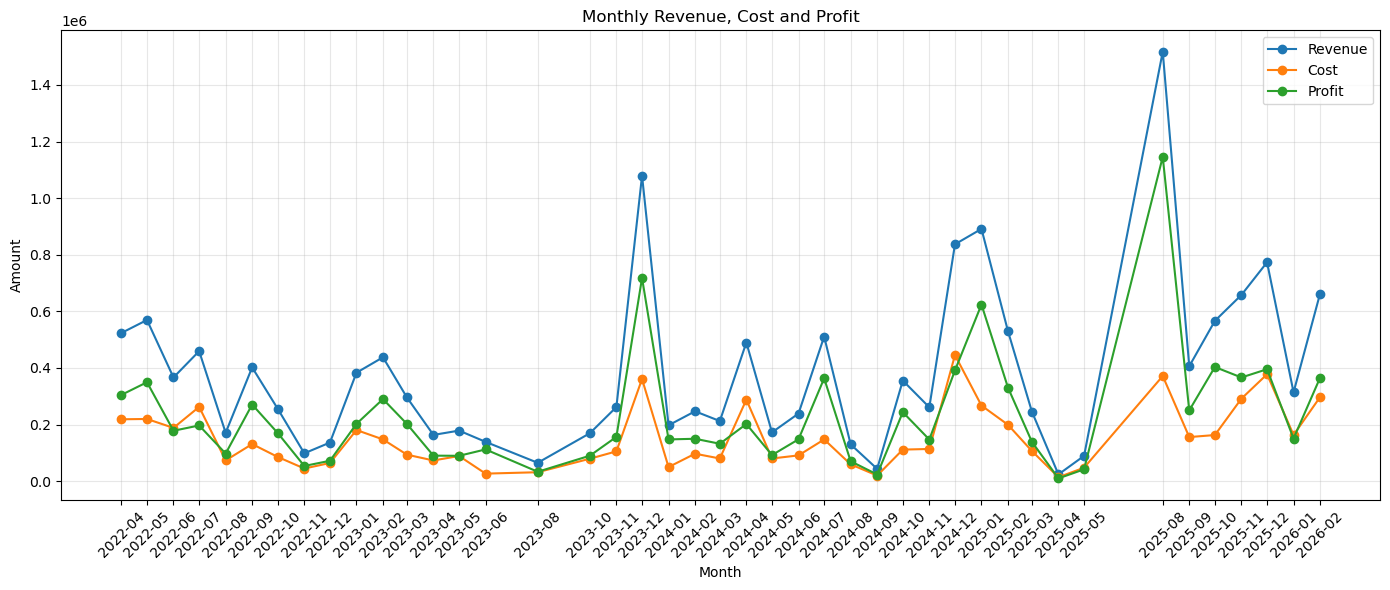

In [153]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(monthly_stats.index, monthly_stats["monthly_total_revenue"], marker="o", label="Revenue")
plt.plot(monthly_stats.index, monthly_stats["montly_order_cost"], marker="o", label="Cost")
plt.plot(monthly_stats.index, monthly_stats["profit"], marker="o", label="Profit")

# FORCER toutes les dates
plt.xticks(monthly_stats.index, monthly_stats.index.strftime("%Y-%m"), rotation=45)

plt.xlabel("Month")
plt.ylabel("Amount")
plt.title("Monthly Revenue, Cost and Profit")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Monthly Revenue, Cost and Profit Analysis

The figure shows the evolution of monthly revenue, cost, and profit for Épiphanie Boutique.

Several patterns emerge from the data.

First, revenue and profit move closely together over time, indicating that profit is largely driven by sales volume. Since the cost line remains significantly below revenue, the business appears to operate with relatively strong margins across most months.

Second, there is noticeable variability in monthly performance. Some months show relatively low sales activity, while others display strong spikes in revenue and profit. For example, there is a major peak around August 2025. This corresponds to the reopening of the physical store. The store had been closed for approximately three months between May and August, which explains the absence of data during that period.

Third, a significant share of sales occurs around November and December, suggesting a seasonal pattern consistent with peak shopping periods at the end of the year.


### Which products generate the highest profit? Which items are the best-selling products? (Q1 and Q2)


In [161]:
product_revenue = (
    df.groupby("ProductType")
      .agg(
          total_revenue=("line_revenue","sum"),
          total_cost=("line_cost","sum"),
          units_sold=("Lineitem quantity","sum"),
          discount = ("Refunded Amount", "max"),
          refunded=("Refunded Amount","max"),
      )
      .sort_values("total_revenue", ascending=False)
)

product_revenue["net_revenue"] = product_revenue["total_revenue"] - product_revenue["refunded"]
product_revenue["profit"] = product_revenue["net_revenue"] - product_revenue["total_cost"]
product_revenue["margin"] = product_revenue["profit"] / product_revenue["net_revenue"]
product_revenue["revenue_share"] = (product_revenue["net_revenue"] /product_revenue["net_revenue"].sum())

product_revenue.head(10)


,total_revenue,total_cost,units_sold,discount,refunded,net_revenue,profit,margin,revenue_share
ProductType,,,,,,,,,
Shoes,9083375,4755552.0,473,40000.0,40000.0,9043375.0,4287823.0,0.474140,0.761793
Beauty,1495870,1000870.0,137,23163.0,23163.0,1472707.0,471837.0,0.320388,0.124057
Bags,631000,367443.0,40,12500.0,12500.0,618500.0,251057.0,0.405913,0.052101
Accessories,378000,195930.0,79,3500.0,3500.0,374500.0,178570.0,0.476822,0.031547
Make up,362085,234036.0,40,0.0,0.0,362085.0,128049.0,0.353643,0.030501


Shoes clearly dominate the store’s performance, generating the highest sales volume, revenue, and total profit. This confirms that footwear represents the core product category of Épiphanie Boutique.

However, when examining profit margins, accessories appear to be the most efficient category, with the highest margin among all product types. Although they sell in lower volumes, they may contribute significantly to overall profitability.

This suggests a typical retail structure where high-volume products (such as shoes) drive traffic and revenue, while complementary products (such as accessories) help increase margins and basket value.

## What are the most demanded shoe sizes? (Q3)


In [160]:
shoes_df = df[df["ProductType"] == "Shoes"]
shoe_sizes = (
    shoes_df.groupby("Shoe Size")
    .agg(
        units_sold=("Lineitem quantity","sum"),
        revenue=("line_revenue","sum"),
        orders=("Name","nunique")
    )
    .sort_values("units_sold", ascending=False)
)

shoe_sizes.head(10)


,units_sold,revenue,orders
Shoe Size,,,
40.0,110,2144325,109
39.0,101,1957300,100
41.0,93,1875000,93
38.0,58,1092000,58
42.0,40,813500,40
37.0,26,535500,26
43.0,4,73750,4
36.0,3,60000,3


### Most Demanded Shoe Sizes

To understand customer demand for footwear, I analyze the number of units sold for each shoe size within the "Shoes" category.

These results suggest that the store’s core customer base mainly purchases shoes in the **39–41 size range**, with size **40 being the most popular**.

Mid-range sizes such as **38 and 42** also display moderate demand, while smaller sizes (**36 and 37**) and larger sizes (**43**) appear much less frequently in orders.

From an inventory perspective, this insight suggests that stocking a higher proportion of sizes **39, 40, and 41** could help reduce stockouts and better match customer demand, while maintaining smaller inventories of less demanded sizes.

## Q5: Does opening a physical store change sales? 


In August 2025, Épiphanie Boutique opened its first physical store. Before that, the business operated exclusively online.

An interesting question is whether opening a physical location affected the volume of sales. In particular, we want to examine whether monthly revenue increased after the store opening.

To explore this question, we compare sales before and after August 2025 using monthly revenue data. This allows us to evaluate whether the introduction of a physical store coincides with a change in the store’s sales performance.


In [166]:
monthly_stats["post_store_opening"] = (
    monthly_stats.index > "2025-08-01" #Exclude that day !
).astype(int)

In [167]:
before_after_sales = (
    monthly_stats.groupby("post_store_opening")["monthly_total_revenue"]
    .mean()
)

before_after_sales

post_store_opening
0    355421.972973
1    563395.833333
Name: monthly_total_revenue, dtype: float64

In [168]:
from scipy.stats import ttest_ind

before = monthly_stats.loc[
    monthly_stats["post_store_opening"] == 0,
    "monthly_total_revenue"
]

after = monthly_stats.loc[
    monthly_stats["post_store_opening"] == 1,
    "monthly_total_revenue"
]

ttest_ind(after, before)

TtestResult(statistic=np.float64(1.601814734526458), pvalue=np.float64(0.11687432106037626), df=np.float64(41.0))

### Impact of Opening a Physical Store on Sales

In August 2025, Épiphanie Boutique opened its first physical store.  
Prior to this, the business operated exclusively online. To evaluate whether the store opening affected sales, I compared average monthly revenue before and after the opening.

Average monthly revenue increased from **355,422** before the store opening to **563,396** after the opening, representing an increase of approximately **58%**.

To test whether this difference is statistically significant, I performed a two-sample t-test comparing monthly revenues before and after the store opening.

The test produced a **p-value of 0.117**, which is above the conventional 5% significance threshold. This means that while sales appear higher after the store opening, the difference is **not statistically significant** given the available data.

This result may be explained by the relatively small number of months observed after the opening and the high variability in monthly sales.